In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [2]:
df = pd.read_csv('../data/Mall_Customers.csv')

df.shape

(200, 5)

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

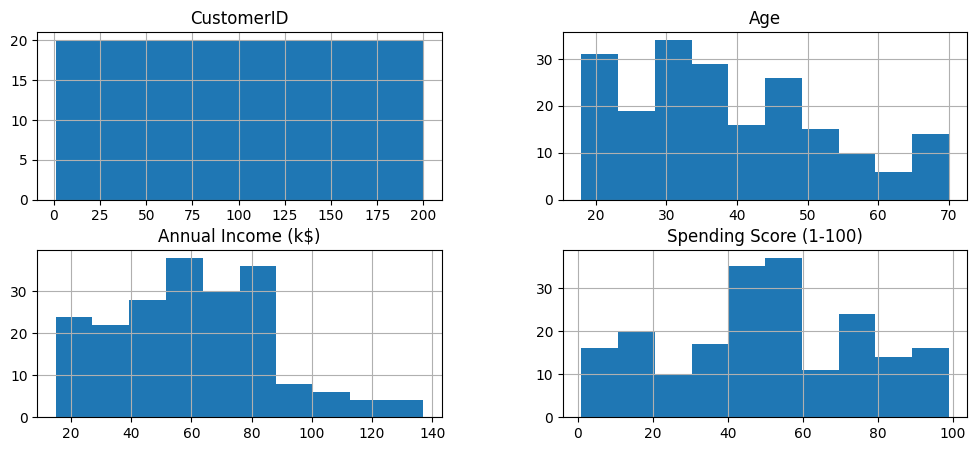

In [7]:
df.hist(figsize=(12,5))
plt.show()

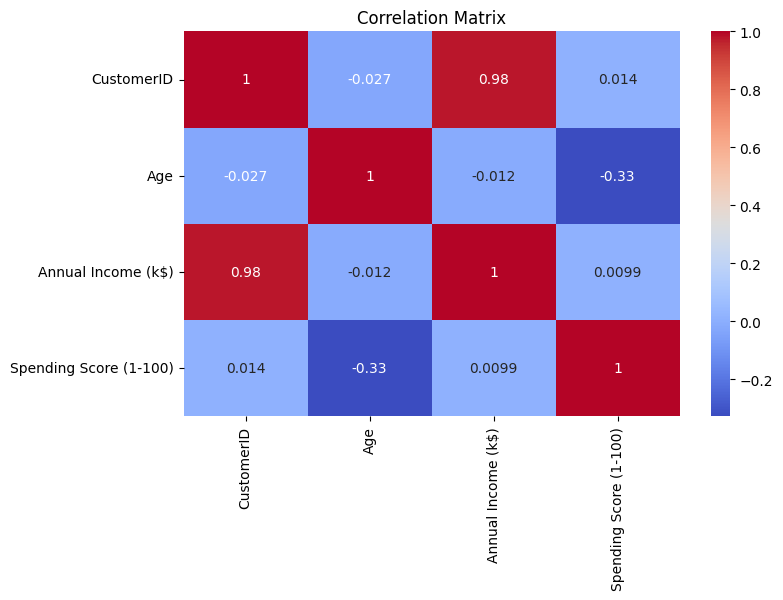

In [8]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
features = ['Annual Income (k$)',
            'Spending Score (1-100)']

X = df[features]

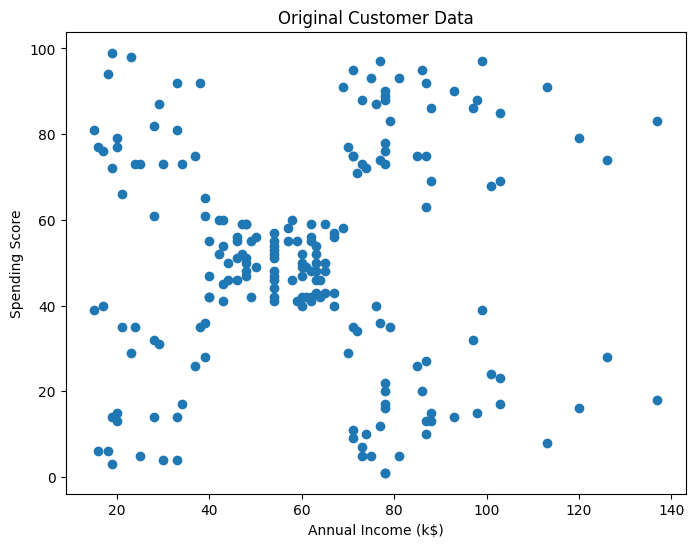

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Original Customer Data')
plt.show()

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


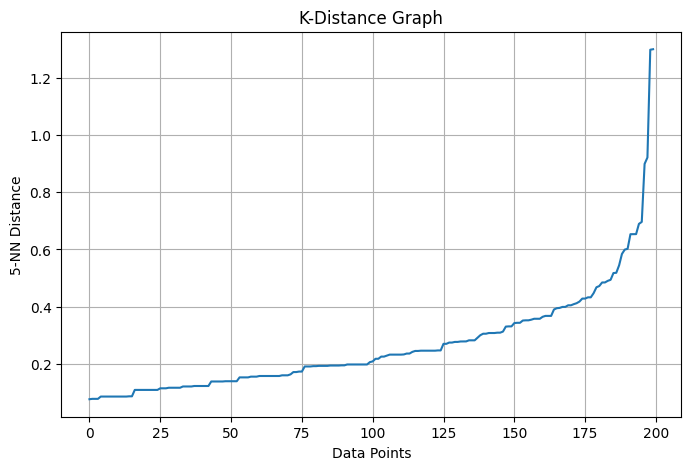

In [ ]:
neighbors = NearestNeighbors(
    n_neighbors=5 #for each point, find its 5 nearest neighbors
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(
    distances[:,4]
)

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.xlabel('Data Points')
plt.ylabel('5-NN Distance')
plt.title('K-Distance Graph')
plt.grid()
plt.show()

In [ ]:
dbscan = DBSCAN(
    eps=0.4, # epsilom is the maximum distance between two samples for them to be considered as in the same neighborhood
    min_samples=5 # minimum number of points required to form a cluster
)

clusters = dbscan.fit_predict(X_scaled)

In [15]:
df['Cluster'] = clusters

In [16]:
df['Cluster'].value_counts()

Cluster
 0    115
 2     32
 3     27
-1     15
 1     11
Name: count, dtype: int64

In [ ]:
n_clusters = len(set(clusters)) #length of unique cluster labels

if -1 in clusters:
    n_clusters -= 1

print("Number of Clusters:", n_clusters)

Number of Clusters: 4


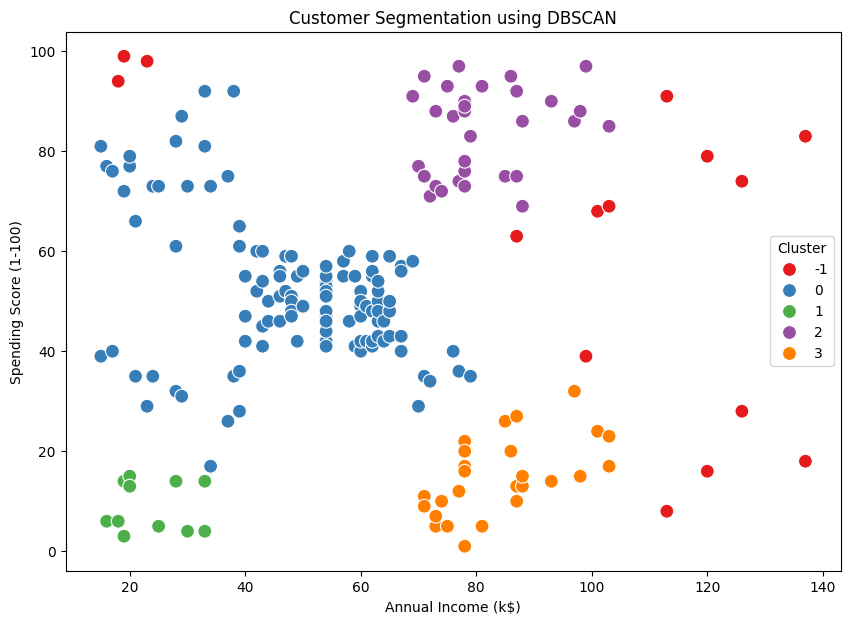

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster', #color the points based on cluster labels
    data=df,
    palette='Set1', #chooses a color scheme
    s=100 #size of the points
)

plt.title('Customer Segmentation using DBSCAN')
plt.show()

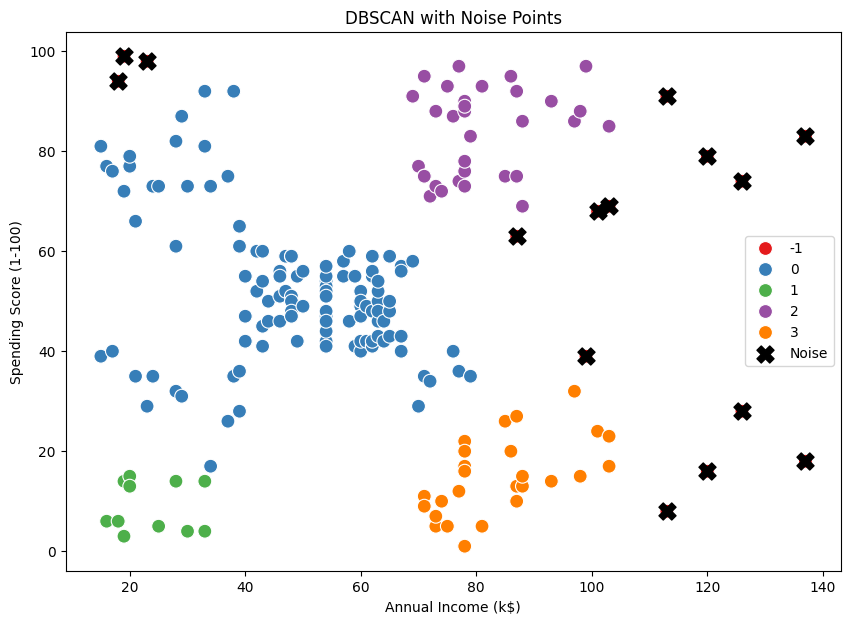

In [19]:
noise = df[df['Cluster'] == -1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100
)

plt.scatter(
    noise['Annual Income (k$)'],
    noise['Spending Score (1-100)'],
    color='black',
    s=150,
    marker='X',
    label='Noise'
)

plt.legend()
plt.title('DBSCAN with Noise Points')
plt.show()

In [21]:
for i in sorted(df['Cluster'].unique()):
    print("\nCluster", i)
    print(df[df['Cluster'] == i].head())


Cluster -1
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
7             8  Female   23                  18                      94   
11           12  Female   35                  19                      99   
19           20  Female   35                  23                      98   
169         170    Male   32                  87                      63   
184         185  Female   41                  99                      39   

     Cluster  
7         -1  
11        -1  
19        -1  
169       -1  
184       -1  

Cluster 0
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17              

In [20]:
df.groupby('Cluster')[
    ['Age',
     'Annual Income (k$)',
     'Spending Score (1-100)']
].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
-1,34.533333,96.133333,61.800000
0,39.539130,48.304348,51.730435
1,49.363636,23.727273,8.909091
2,32.750000,80.875000,83.625000
3,41.259259,83.925926,14.444444
